# BRANCH 2 : Modeling (Entraînement & Optimisation) - Model Training
**Responsables :** Matthias Defretin, Romain Lesueur

## 1. Import des librairies

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Chargement et Préparation des Données

In [25]:
path = 'DATA'
filename = 'application_train_cleaned.csv'

if os.path.exists(os.path.join(path, filename)):
    df = pd.read_csv(os.path.join(path, filename))
    print(f"Dataset chargé : {df.shape}")
else:
    print("Erreur : Le fichier n'existe pas. Veuillez exécuter preprocessing.ipynb d'abord.")

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

del df
gc.collect()

Dataset chargé : (307511, 287)


8814

In [26]:
X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape : {X_train.shape}")
print(f"Test shape : {X_test.shape}")

Train shape : (246008, 285)
Test shape : (61503, 285)


In [27]:
print("Encodage des variables catégorielles en cours...")
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='inner', axis=1)
print(f"Nouvelles dimensions après encodage : Train {X_train.shape}, Test {X_test.shape}")

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

print("Imputation et Scaling en cours...")
X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_scaled = scaler.transform(imputer.transform(X_test))
print("Préprocessing terminé.")

Encodage des variables catégorielles en cours...
Nouvelles dimensions après encodage : Train (246008, 408), Test (61503, 408)
Imputation et Scaling en cours...
Préprocessing terminé.


## 3. Modélisation

### 3.1 Baseline : Dummy Classifier
Un modèle naïf qui prédit toujours la classe majoritaire (0). Il nous sert de référence minimale.

In [28]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict_proba(X_test)[:, 1]
auc_dummy = roc_auc_score(y_test, y_pred_dummy)

print(f"Baseline ROC AUC : {auc_dummy:.4f}")

Baseline ROC AUC : 0.5000


### 3.2 Régression Logistique (avec Class Weight)
Modèle linéaire simple et interprétable.

In [29]:
lr = LogisticRegression(C=1.0, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr)

print(f"Logistic Regression ROC AUC : {auc_lr:.4f}")

Logistic Regression ROC AUC : 0.7658


### 3.3 Random Forest

In [30]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

rf.fit(X_train_imputed, y_train)

y_pred_rf = rf.predict_proba(X_test_imputed)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_rf)

print(f"Random Forest ROC AUC : {auc_rf:.4f}")

Random Forest ROC AUC : 0.7457


### 3.4 XGBoost (Gradient Boosting)
Souvent le plus performant sur ce type de données.

In [31]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)

print(f"XGBoost ROC AUC : {auc_xgb:.4f}")

C:\Users\EkiaN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:199: UserWarning: [17:05:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost ROC AUC : 0.7785


## 4. Comparaison et Feature Importance

C:\Users\EkiaN\AppData\Local\Temp\ipykernel_10484\2874634109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC', y='Model', data=results.sort_values('AUC', ascending=False), palette='viridis')


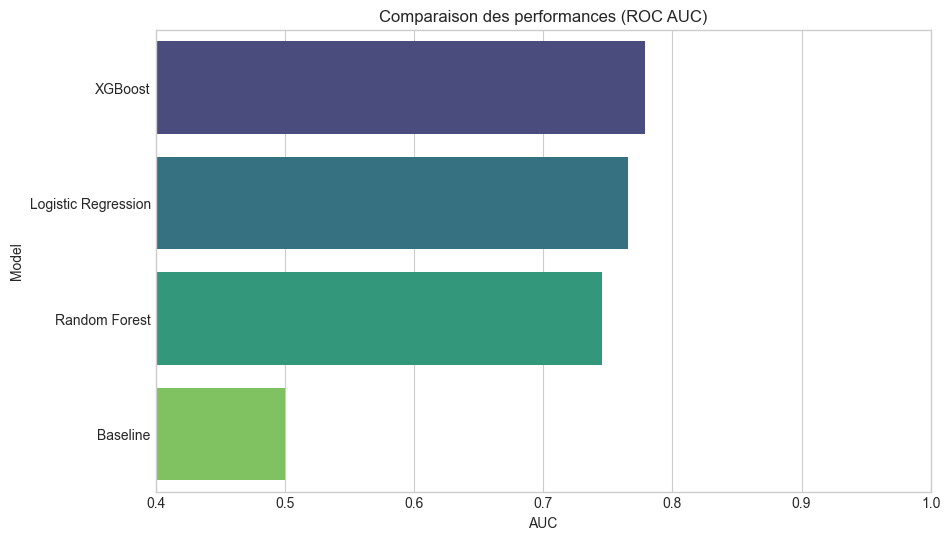

In [32]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC': [auc_dummy, auc_lr, auc_rf, auc_xgb]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='AUC', y='Model', data=results.sort_values('AUC', ascending=False), palette='viridis')
plt.title('Comparaison des performances (ROC AUC)')
plt.xlim(0.4, 1.0)
plt.show()

C:\Users\EkiaN\AppData\Local\Temp\ipykernel_10484\3348521009.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='magma')


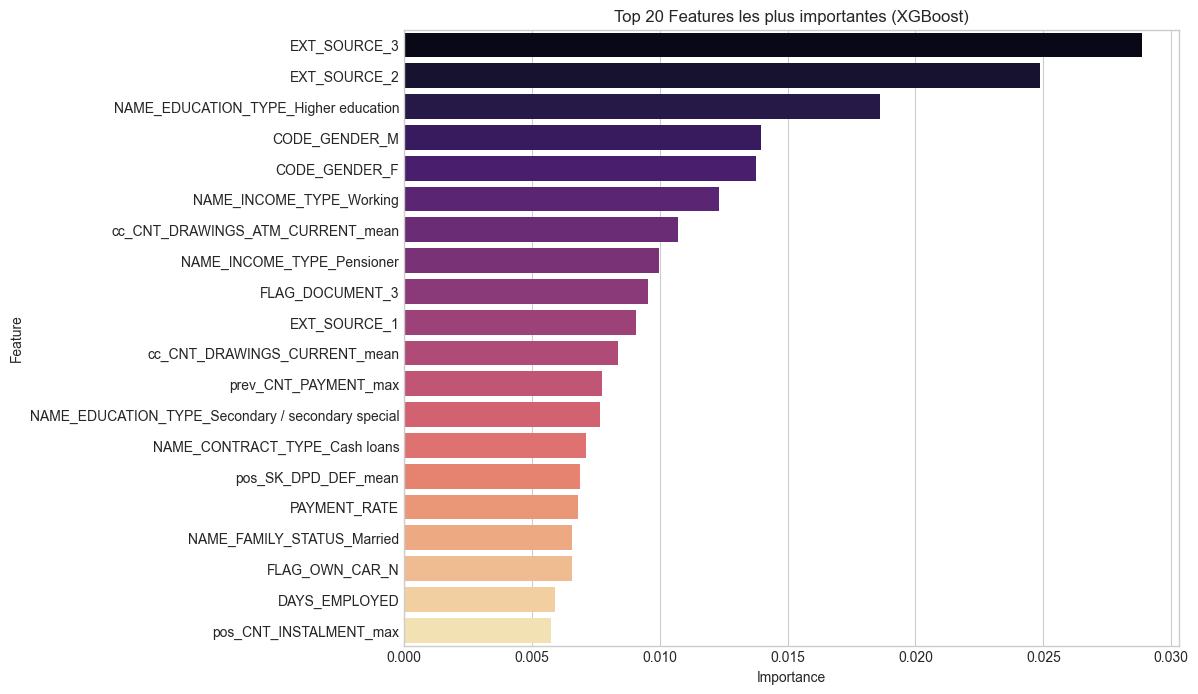

Top 15 features sélectionnées pour l'application : ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'NAME_EDUCATION_TYPE_Higher education', 'CODE_GENDER_M', 'CODE_GENDER_F', 'NAME_INCOME_TYPE_Working', 'cc_CNT_DRAWINGS_ATM_CURRENT_mean', 'NAME_INCOME_TYPE_Pensioner', 'FLAG_DOCUMENT_3', 'EXT_SOURCE_1', 'cc_CNT_DRAWINGS_CURRENT_mean', 'prev_CNT_PAYMENT_max', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_CONTRACT_TYPE_Cash loans', 'pos_SK_DPD_DEF_mean']


C:\Users\EkiaN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:199: UserWarning: [17:05:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost (Top 15 Features) ROC AUC : 0.7422


In [33]:
feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='magma')
plt.title('Top 20 Features les plus importantes (XGBoost)')
plt.show()

top_features = feature_imp['Feature'].head(15).tolist()
print("Top 15 features sélectionnées pour l'application :", top_features)

X_train_small = X_train[top_features]
X_test_small = X_test[top_features]

xgb_small = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_small.fit(X_train_small, y_train)

y_pred_small = xgb_small.predict_proba(X_test_small)[:, 1]
auc_small = roc_auc_score(y_test, y_pred_small)
print(f"XGBoost (Top 15 Features) ROC AUC : {auc_small:.4f}")

## 5. Sauvegarde du Modèle
On sauvegarde le meilleur modèle pour l'utiliser dans l'application Streamlit.

In [34]:
joblib.dump(xgb_small, 'best_model_xgb_small.pkl')
print("Modèle simplifié sauvegardé sous 'best_model_xgb_small.pkl'")

joblib.dump(top_features, 'model_features_small.pkl')

Modèle simplifié sauvegardé sous 'best_model_xgb_small.pkl'


['model_features_small.pkl']